### Compute correlation between features and STAI

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
all_features=pd.read_csv('../data/extracted/features.csv')
all_features.head()

,PupilMean,PupilStd,PupilIQR,PulseMean,PulseStd,PulseIQR,MotionMean,MotionStd,GazeXSpread,GazeYSpread,...,deltapop_break_GazeZStd,PupilSlope,PulseSlope,STAI_T,STAI_S,Gender,Handedness,WearsGlasses,CalibrationError,BloodType
0,3.771768,0.106159,0.208583,71.524527,2.980388,4.330056,0.077918,0.041051,6.346617,3.899692,...,-0.001688,0.030295,0.233015,37,36,F,R,0,0.396519,B
1,4.168104,0.297278,0.540427,63.492698,3.194581,4.697833,0.078477,0.043443,2.595039,5.577476,...,0.000230,0.025635,0.298663,40,39,M,R,1,0.270619,B
2,2.936875,0.257140,0.386328,69.680790,2.990567,4.020886,0.078204,0.043216,9.888315,9.176159,...,0.001296,-0.000291,0.012695,34,30,M,L,1,0.387328,O
3,2.919887,0.265092,0.380598,62.292389,3.033958,3.967144,0.077956,0.041032,5.633180,3.869062,...,0.000134,-0.010786,-0.067326,25,40,M,R,0,0.263703,O
4,4.434019,0.101365,0.144147,68.934614,3.022857,4.403533,0.078134,0.041994,5.290060,4.489159,...,-0.001306,-0.024938,0.363158,28,29,F,L,0,0.140290,A


##### Correlation Matrix

In [5]:
numeric_feats = all_features.select_dtypes(include=np.number).drop(
    columns=["STAI_T", "STAI_S", "WearsGlasses", "CalibrationError"], errors="ignore"
)

corr_with_stai = pd.DataFrame({
    "corr_STAI_T": numeric_feats.corrwith(all_features["STAI_T"]),
    "corr_STAI_S": numeric_feats.corrwith(all_features["STAI_S"]),
}).dropna().sort_values("corr_STAI_T", key=abs, ascending=False)

corr_with_stai

,corr_STAI_T,corr_STAI_S
delta_break_PupilMedian,0.395968,0.326672
delta_break_PupilMean,0.395121,0.325775
delta_relax_PupilMedian,0.383572,0.314232
delta_relax_PupilMean,0.380668,0.308944
delta_relax_PupilSkew,-0.323480,-0.265621
...,...,...
delta_break_GazeYStd,0.005052,-0.019760
PulseStd,0.004289,0.004247
deltapop_baseline_GazeXStd,0.003972,0.017735
PulseIQR,0.001363,0.012010


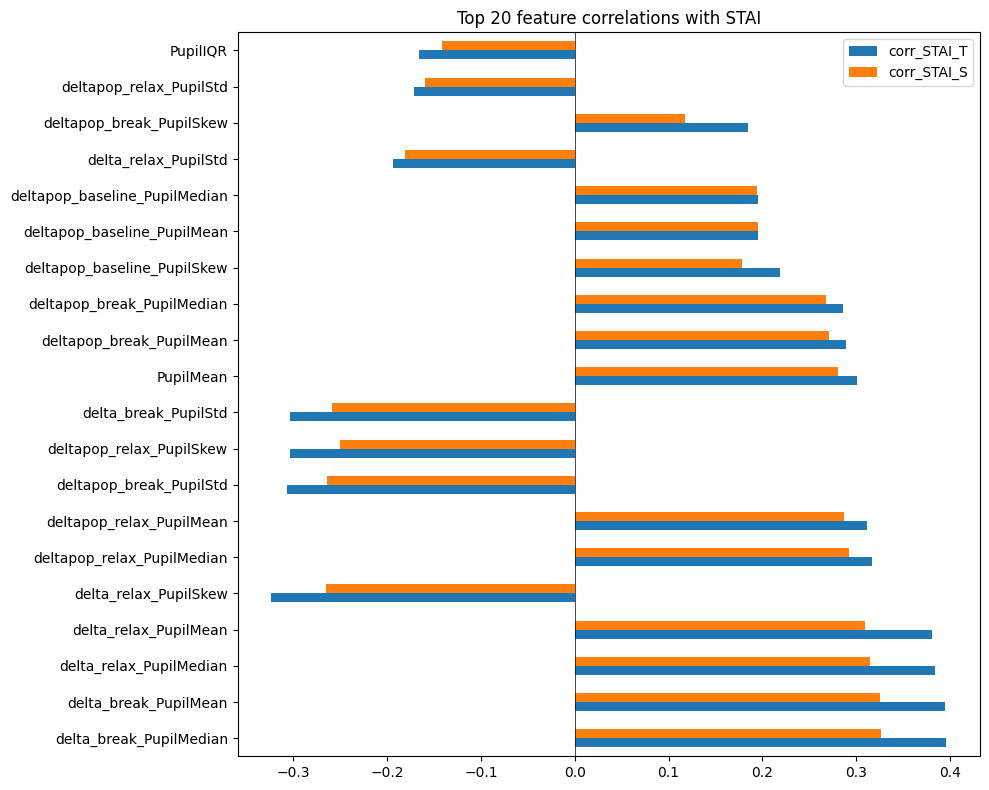

In [6]:
# Top 20 features
fig, ax = plt.subplots(figsize=(10, 8))
corr_with_stai.head(20).plot.barh(ax=ax)
ax.set_title("Top 20 feature correlations with STAI")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()